## Consolidate Imports and Data Loading

### Subtask:
Set up the environment and load the dataset into a single, clean initial block.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/ADY201m/Student Insomnia and Educational Outcomes Dataset_version-2.csv')

print("Environment set up and dataset loaded successfully.")

Environment set up and dataset loaded successfully.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data Preprocessing

### Subtask:
Clean column names and apply numeric mapping for categorical variables in one integrated step.


In [ ]:
df.columns = df.columns.str.strip()

full_mapping = {
    'Timestamp': 'Record_Time',
    '1. What is your year of study?': 'Year',
    '2. What is your gender?': 'Gender',
    '3. How often do you have difficulty falling asleep at night?': 'Difficulty_Falling_Asleep',
    '4. On average, how many hours of sleep do you get on a typical day?': 'Sleep_Hours_Total',
    '5. How often do you wake up during the night and have trouble falling back asleep?': 'Waking_Up_During_Night',
    '6. How would you rate the overall quality of your sleep?': 'Overall_Sleep_Quality',
    '7. How often do you experience difficulty concentrating during lectures or studying due to lack of sleep?': 'Sleep_Impact_on_Concentration',
    '8. How often do you feel fatigued during the day, affecting your ability to study or attend classes?': 'Daytime_Fatigue',
    '9. How often do you miss or skip classes due to sleep-related issues (e.g., insomnia, feeling tired)?': 'Sleep_Impact_on_Attendance',
    '10. How would you describe the impact of insufficient sleep on your ability to complete assignments and meet deadlines?': 'Sleep_Impact_on_Deadlines',
    '11. How often do you use electronic devices (e.g., phone, computer) before going to sleep?': 'Phone_Usage_Before_Sleep',
    '12. How often do you consume caffeine (coffee, energy drinks) to stay awake or alert?': 'Caffeine_Intake',
    '13. How often do you engage in physical activity or exercise?': 'Exercise_Frequency',
    '14. How would you describe your stress levels related to academic workload?': 'Academic_Stress_Level',
    '15. How would you rate your overall academic performance (GPA or grades) in the past semester?': 'GPA_Rating'
}
df = df.rename(columns=full_mapping)

freq_map = {
    'Never': 0, 'Rarely': 1, 'Rarely (1-2 times a month)': 1, 'Rarely (1-2 times a week)': 1,
    'Sometimes': 2, 'Sometimes (1-2 times a week)': 2, 'Sometimes (3-4 times a week)': 2,
    'Often': 3, 'Often (3-4 times a week)': 3, 'Often (5-6 times a week)': 3,
    'Always': 4, 'Every day': 4, 'Every night': 4
}
sleep_duration_map = {'Less than 4 hours': 3.5, '4-5 hours': 4.5, '5-6 hours': 5.5, '6-7 hours': 6.5, '7-8 hours': 7.5, 'More than 8 hours': 8.5}
quality_map = {'Very poor': 1, 'Poor': 2, 'Average': 3, 'Good': 4, 'Very good': 5}
impact_map = {'No impact': 0, 'Minor impact': 1, 'Moderate impact': 2, 'Major impact': 3, 'Severe impact': 4}
stress_map = {'No stress': 0, 'Low stress': 1, 'High stress': 2, 'Extremely high stress': 3}
gpa_map = {'Poor': 1, 'Below Average': 2, 'Average': 3, 'Good': 4, 'Excellent': 5}
year_map = {'First year': 1, 'Second year': 2, 'Third year': 3, 'Graduate student': 4}
gender_map = {'Male': 0, 'Female': 1}

cols_freq = ['Difficulty_Falling_Asleep', 'Waking_Up_During_Night', 'Sleep_Impact_on_Concentration',
             'Daytime_Fatigue', 'Sleep_Impact_on_Attendance', 'Phone_Usage_Before_Sleep',
             'Caffeine_Intake', 'Exercise_Frequency']
for col in cols_freq: df[col] = df[col].map(freq_map)

df['Sleep_Hours_Total'] = df['Sleep_Hours_Total'].map(sleep_duration_map)
df['Overall_Sleep_Quality'] = df['Overall_Sleep_Quality'].map(quality_map)
df['Sleep_Impact_on_Deadlines'] = df['Sleep_Impact_on_Deadlines'].map(impact_map)
df['Academic_Stress_Level'] = df['Academic_Stress_Level'].map(stress_map)
df['GPA_Rating'] = df['GPA_Rating'].map(gpa_map)
df['Year'] = df['Year'].map(year_map)
df['Gender'] = df['Gender'].map(gender_map)

display(df.head())

,Record_Time,Year,Gender,Difficulty_Falling_Asleep,Sleep_Hours_Total,Waking_Up_During_Night,Overall_Sleep_Quality,Sleep_Impact_on_Concentration,Daytime_Fatigue,Sleep_Impact_on_Attendance,Sleep_Impact_on_Deadlines,Phone_Usage_Before_Sleep,Caffeine_Intake,Exercise_Frequency,Academic_Stress_Level,GPA_Rating
0,10/24/2024 16:51:15,4,0,3,7.5,3,4,2,3,3,2,3,1,2,2,3
1,10/24/2024 16:51:51,3,0,3,7.5,3,4,3,2,2,3,2,2,2,1,4
2,10/24/2024 16:52:21,1,1,2,7.5,2,4,3,3,2,3,3,3,3,2,2
3,10/24/2024 16:53:00,3,0,3,8.5,2,2,3,3,1,1,2,2,4,3,5
4,10/24/2024 16:53:25,4,0,3,7.5,3,5,4,2,2,2,2,2,3,1,3


## Integrated Data Cleaning and Feature Engineering

### Subtask:
Filter contradictory data rows and generate synthetic features for the analysis.


In [ ]:
# Feature Engineering
df['Academic_Burnout_Score'] = df['Sleep_Impact_on_Deadlines'] * df['Sleep_Impact_on_Concentration']
df['Sleep_Hygiene_Risk'] = df['Phone_Usage_Before_Sleep'] * df['Difficulty_Falling_Asleep']

df['Invalid_Data_Points'] = 0

# 1. High difficulty falling asleep but Very good quality
df.loc[(df['Sleep_Hygiene_Risk'] >= 16) & (df['Overall_Sleep_Quality'] >= 4), 'Invalid_Data_Points'] += 1

# 2. Very low sleep hours but No fatigue
df.loc[(df['Sleep_Hours_Total'] <= 3.5) & (df['Daytime_Fatigue'] <= 1), 'Invalid_Data_Points'] += 1

# 3. High Burnout but No stress
df.loc[(df['Academic_Burnout_Score'] >= 16) & (df['Academic_Stress_Level'] <= 1), 'Invalid_Data_Points'] += 1

# Filter to create df_clean and drop the tracker column
df_clean = df[df['Invalid_Data_Points'] == 0].copy()
df_clean = df_clean.drop(columns=['Invalid_Data_Points'])

print(f"Rows removed: {len(df) - len(df_clean)}")
print(f"Cleaned dataset size: {len(df_clean)}")
display(df_clean.head())

Rows removed: 121
Cleaned dataset size: 875


,Record_Time,Year,Gender,Difficulty_Falling_Asleep,Sleep_Hours_Total,Waking_Up_During_Night,Overall_Sleep_Quality,Sleep_Impact_on_Concentration,Daytime_Fatigue,Sleep_Impact_on_Attendance,Sleep_Impact_on_Deadlines,Phone_Usage_Before_Sleep,Caffeine_Intake,Exercise_Frequency,Academic_Stress_Level,GPA_Rating,Academic_Burnout_Score,Sleep_Hygiene_Risk
0,10/24/2024 16:51:15,4,0,3,7.5,3,4,2,3,3,2,3,1,2,2,3,4,9
1,10/24/2024 16:51:51,3,0,3,7.5,3,4,3,2,2,3,2,2,2,1,4,9,6
2,10/24/2024 16:52:21,1,1,2,7.5,2,4,3,3,2,3,3,3,3,2,2,9,6
3,10/24/2024 16:53:00,3,0,3,8.5,2,2,3,3,1,1,2,2,4,3,5,3,6
4,10/24/2024 16:53:25,4,0,3,7.5,3,5,4,2,2,2,2,2,3,1,3,8,6


## Exploratory Data Analysis (EDA)

### Subtask:
Generate a correlation matrix and distribution plots for the cleaned features in `df_clean` to identify key relationships.


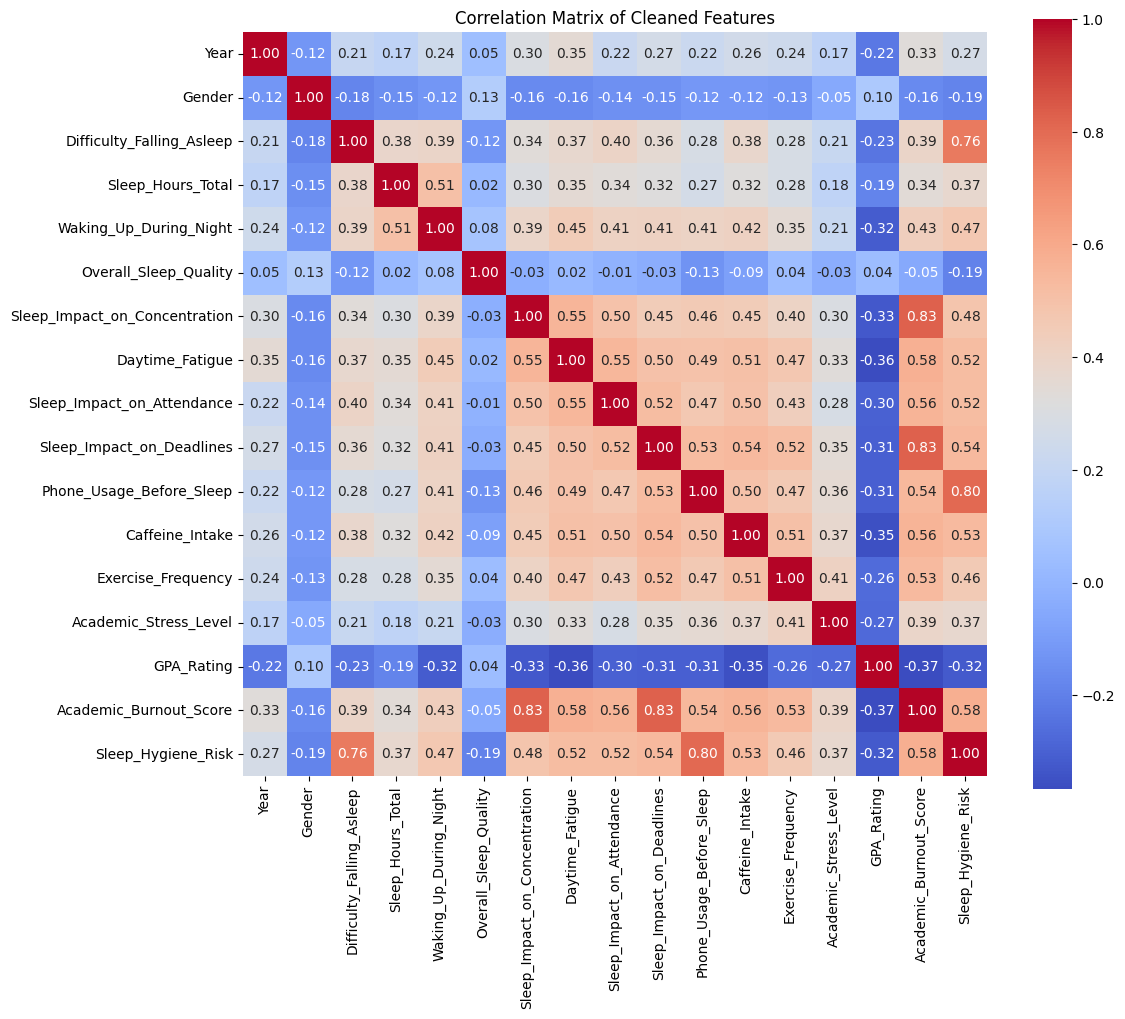

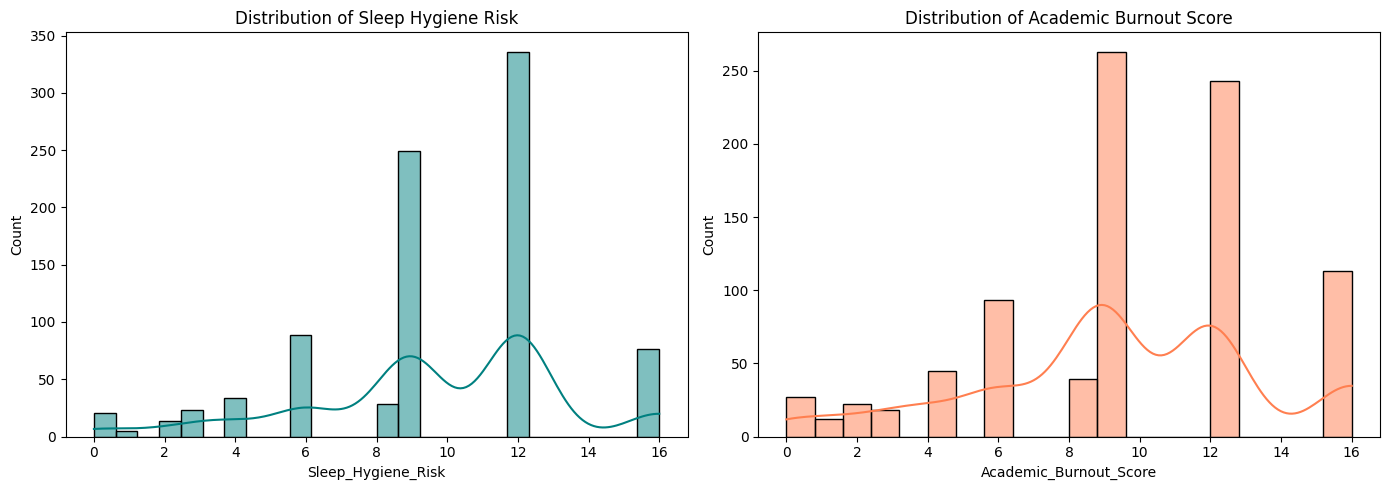

/tmp/ipykernel_9991/1635992986.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='GPA_Rating', y='Academic_Stress_Level', data=df_clean, palette='viridis')


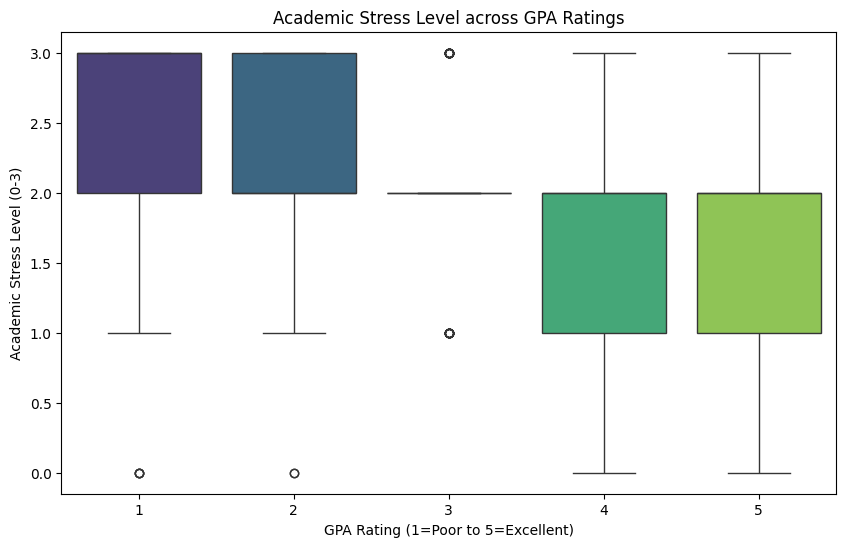

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate Correlation Matrix
corr_matrix = df_clean.corr(numeric_only=True)

# 2. Visualize Correlation Matrix
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix of Cleaned Features')
plt.show()

# 3. Distribution plots for engineered features
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_clean['Sleep_Hygiene_Risk'], kde=True, color='teal')
plt.title('Distribution of Sleep Hygiene Risk')

plt.subplot(1, 2, 2)
sns.histplot(df_clean['Academic_Burnout_Score'], kde=True, color='coral')
plt.title('Distribution of Academic Burnout Score')

plt.tight_layout()
plt.show()

# 4. Relationship between Academic Stress and GPA Rating
plt.figure(figsize=(10, 6))
sns.boxplot(x='GPA_Rating', y='Academic_Stress_Level', data=df_clean, palette='viridis')
plt.title('Academic Stress Level across GPA Ratings')
plt.xlabel('GPA Rating (1=Poor to 5=Excellent)')
plt.ylabel('Academic Stress Level (0-3)')
plt.show()

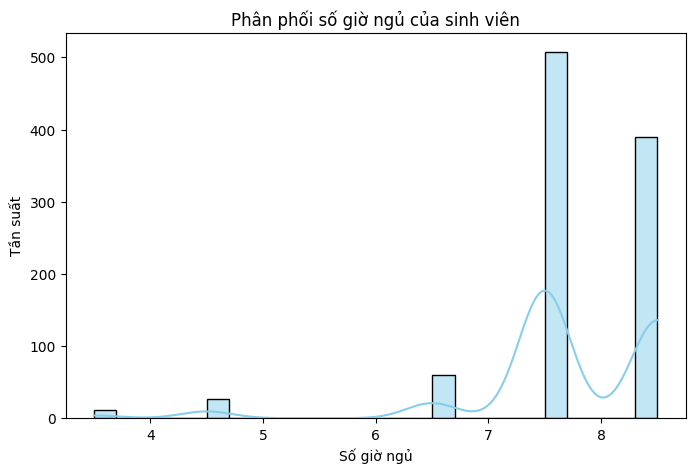

/tmp/ipykernel_9991/2083549522.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y='Academic_Stress_Level', data=df, palette='Set2')


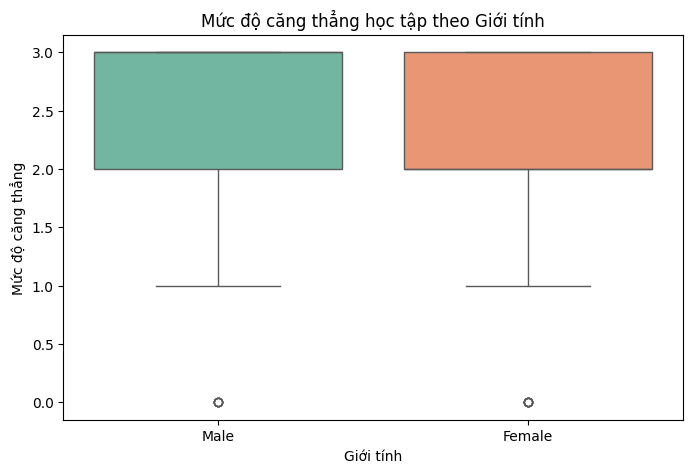

In [ ]:

# 3. Histogram phân phối của số giờ ngủ (RQ1)
plt.figure(figsize=(8, 5))
sns.histplot(df['Sleep_Hours_Total'], kde=True, color='skyblue')
plt.title('Phân phối số giờ ngủ của sinh viên')
plt.xlabel('Số giờ ngủ')
plt.ylabel('Tần suất')
plt.show()

# 4. Boxplot so sánh mức độ căng thẳng giữa Nam và Nữ (RQ2)
plt.figure(figsize=(8, 5))
sns.boxplot(x='Gender', y='Academic_Stress_Level', data=df, palette='Set2')
plt.title('Mức độ căng thẳng học tập theo Giới tính')
plt.xticks([0, 1], ['Male', 'Female'])
plt.xlabel('Giới tính')
plt.ylabel('Mức độ căng thẳng')
plt.show()

## Model Training and Evaluation



In [ ]:
# --- ANALYSIS ---
features_model = ['Academic_Burnout_Score', 'Sleep_Hygiene_Risk', 'Overall_Sleep_Quality', 'Exercise_Frequency']
X = df_clean[features_model]
y = df_clean['Academic_Stress_Level']
X_full_ols = sm.add_constant(X)
ols_analysis_model = sm.OLS(y, X_full_ols).fit()

print("\n" + "="*50)
print("--- KẾT QUẢ PHÂN TÍCH NHÂN QUẢ (ANALYSIS) ---")
print("Bảng hệ số tác động (Coefficients) cho biết Hướng và Độ mạnh:")
print(ols_analysis_model.params.sort_values(ascending=False))
print("\nBảng chi tiết:")
print(ols_analysis_model.summary())
print("="*50)


--- KẾT QUẢ PHÂN TÍCH NHÂN QUẢ (ANALYSIS) ---
Bảng hệ số tác động (Coefficients) cho biết Hướng và Độ mạnh:
const                     1.212228
Exercise_Frequency        0.205064
Sleep_Hygiene_Risk        0.029897
Academic_Burnout_Score    0.025362
Overall_Sleep_Quality    -0.002088
dtype: float64

Bảng chi tiết:
                              OLS Regression Results                             
Dep. Variable:     Academic_Stress_Level   R-squared:                       0.228
Model:                               OLS   Adj. R-squared:                  0.225
Method:                    Least Squares   F-statistic:                     64.29
Date:                   Mon, 23 Mar 2026   Prob (F-statistic):           1.20e-47
Time:                           07:40:02   Log-Likelihood:                -766.58
No. Observations:                    875   AIC:                             1543.
Df Residuals:                        870   BIC:                             1567.
Df Model:                    

In [ ]:
# 1. Define feature matrix X and target vector y
features_model = ['Academic_Burnout_Score', 'Sleep_Hygiene_Risk', 'Overall_Sleep_Quality', 'Exercise_Frequency', 'GPA_Rating', 'Sleep_Hours_Total' ]
X = df_clean[features_model]
y = df_clean['Academic_Stress_Level']

# 2. Split the data into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats # Import scipy.stats

# Interval Estimation and Hypothesis Testing
# RQ1: Ước lượng khoảng tin cậy 95% cho số giờ ngủ trung bình của toàn bộ sinh viên
print("--- RQ1: 95% Confidence Interval for Sleep Hours ---")
sleep_data = df['Sleep_Hours_Total'].dropna()
mean_sleep = np.mean(sleep_data)
std_err = stats.sem(sleep_data) # Tính sai số chuẩn (Standard Error)
ci_95 = stats.t.interval(confidence=0.95, df=len(sleep_data)-1, loc=mean_sleep, scale=std_err)

print(f"Số giờ ngủ trung bình của mẫu: {mean_sleep:.2f} giờ")
print(f"Khoảng tin cậy 95%: Dân số sinh viên có số giờ ngủ trung bình nằm trong khoảng từ {ci_95[0]:.2f} đến {ci_95[1]:.2f} giờ\n")

# RQ2: Kiểm định sự khác biệt về mức độ căng thẳng giữa Nam và Nữ (Two-sample t-test)
print("--- RQ2: T-test for Academic Stress Level (Male vs Female) ---")
male_stress = df[df['Gender'] == 0]['Academic_Stress_Level'].dropna() # Corrected gender mapping
female_stress = df[df['Gender'] == 1]['Academic_Stress_Level'].dropna() # Corrected gender mapping

t_stat_gender, p_val_gender = stats.ttest_ind(male_stress, female_stress, equal_var=False)
print(f"Test Statistic (T): {t_stat_gender:.4f}")
print(f"P-value: {p_val_gender:.4f}")

if p_val_gender < 0.05:
    print("Kết luận: P-value < 0.05. Có sự khác biệt có ý nghĩa thống kê về mức độ căng thẳng giữa sinh viên Nam và Nữ (Bác bỏ H0).\n")
else:
    print("Kết luận: P-value >= 0.05. Không đủ bằng chứng để nói có sự khác biệt về mức độ căng thẳng giữa Nam và Nữ.\n")

# RQ3: Kiểm định sự khác biệt GPA giữa nhóm ngủ ngon và nhóm ngủ kém
print("--- RQ3: T-test for GPA (Good Sleep vs Poor Sleep) ---")
good_sleep_gpa = df[df['Overall_Sleep_Quality'] >= 4]['GPA_Rating'].dropna() # Corrected column name
poor_sleep_gpa = df[df['Overall_Sleep_Quality'] < 4]['GPA_Rating'].dropna() # Corrected column name

t_stat_gpa, p_val_gpa = stats.ttest_ind(good_sleep_gpa, poor_sleep_gpa, equal_var=False)
print(f"Test Statistic (T): {t_stat_gpa:.4f}")
print(f"P-value: {p_val_gpa:.4f}")

if p_val_gpa < 0.05:
    print("Kết luận: Nhóm ngủ ngon có GPA khác biệt đáng kể so với nhóm ngủ kém (Bác bỏ H0).")
else:
    print("Kết luận: Chưa thấy sự khác biệt đáng kể về GPA giữa hai nhóm giấc ngủ.")

--- RQ1: 95% Confidence Interval for Sleep Hours ---
Số giờ ngủ trung bình của mẫu: 7.71 giờ
Khoảng tin cậy 95%: Dân số sinh viên có số giờ ngủ trung bình nằm trong khoảng từ 7.65 đến 7.76 giờ

--- RQ2: T-test for Academic Stress Level (Male vs Female) ---
Test Statistic (T): 2.0662
P-value: 0.0393
Kết luận: P-value < 0.05. Có sự khác biệt có ý nghĩa thống kê về mức độ căng thẳng giữa sinh viên Nam và Nữ (Bác bỏ H0).

--- RQ3: T-test for GPA (Good Sleep vs Poor Sleep) ---
Test Statistic (T): -2.3215
P-value: 0.0205
Kết luận: Nhóm ngủ ngon có GPA khác biệt đáng kể so với nhóm ngủ kém (Bác bỏ H0).


## Final Visualization



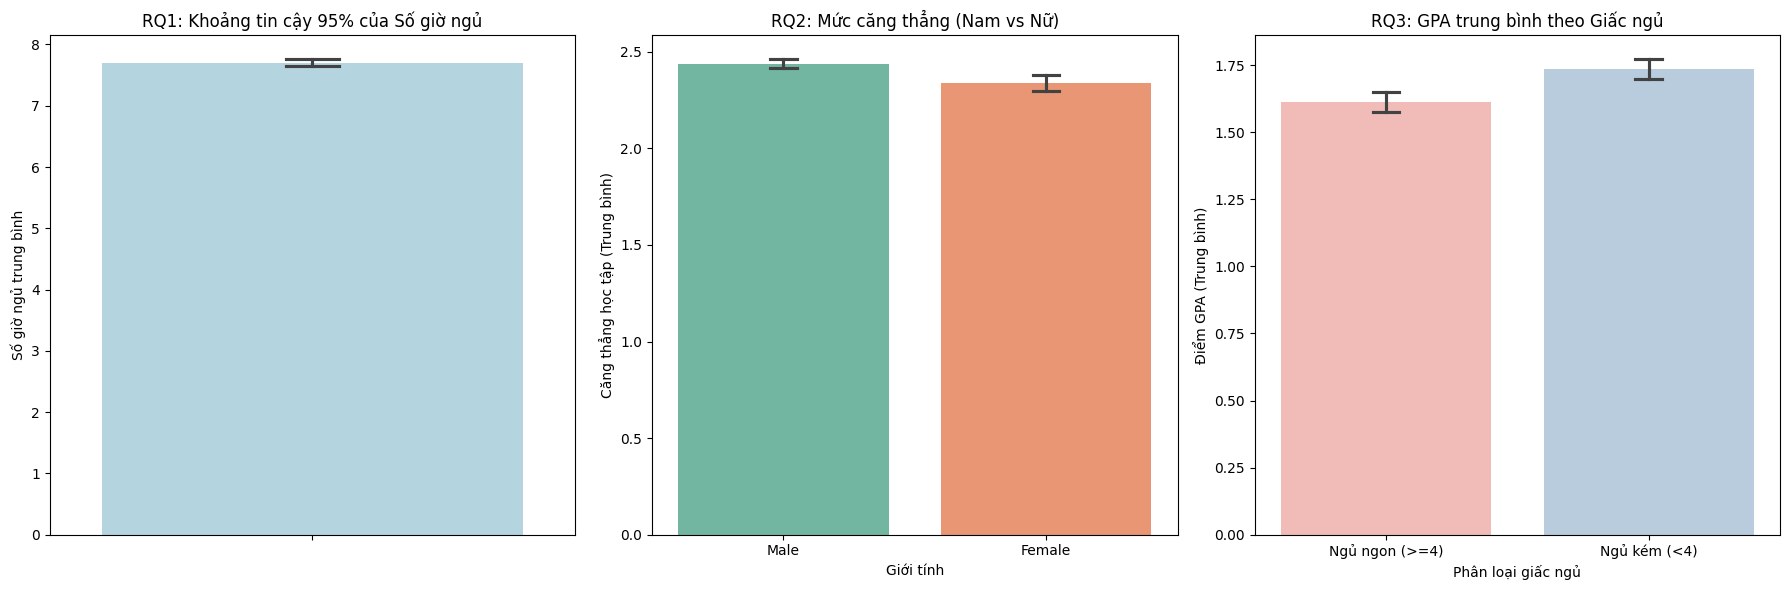

In [ ]:
df['Sleep_Category'] = np.where(df['Overall_Sleep_Quality'] >= 4, 'Ngủ ngon (>=4)', 'Ngủ kém (<4)')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# RQ1: Confidence Interval for Sleep Hours
sns.barplot(y=df['Sleep_Hours_Total'], ax=axes[0], errorbar=('ci', 95), capsize=.1, color='lightblue')
axes[0].set_title('RQ1: Khoảng tin cậy 95% của Số giờ ngủ')
axes[0].set_ylabel('Số giờ ngủ trung bình')

# RQ2: Stress Level by Gender
sns.barplot(x='Gender', y='Academic_Stress_Level', data=df, ax=axes[1], errorbar='se', capsize=.1, palette='Set2', hue='Gender', legend=False)
axes[1].set_title('RQ2: Mức căng thẳng (Nam vs Nữ)')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Male', 'Female'])
axes[1].set_xlabel('Giới tính')
axes[1].set_ylabel('Căng thẳng học tập (Trung bình)')

# RQ3: GPA Rating by Sleep Category
sns.barplot(x='Sleep_Category', y='GPA_Rating', data=df, ax=axes[2], errorbar='se', capsize=.1, palette='Pastel1', hue='Sleep_Category', legend=False)
axes[2].set_title('RQ3: GPA trung bình theo Giấc ngủ')
axes[2].set_xlabel('Phân loại giấc ngủ')
axes[2].set_ylabel('Điểm GPA (Trung bình)')

plt.tight_layout()
plt.show()

Extra cells to split maps for using

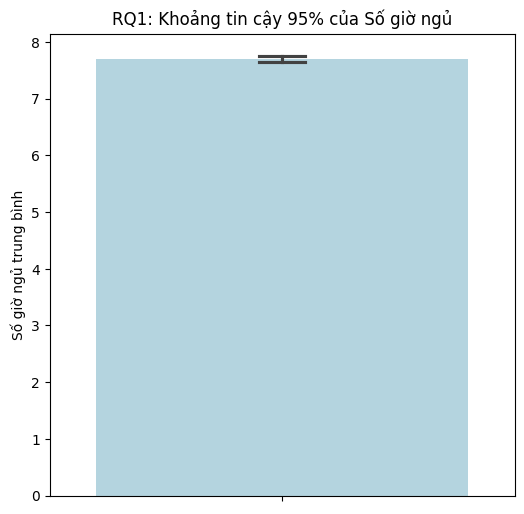

In [ ]:
# RQ1: 95% Confidence Interval for Sleep Hours
plt.figure(figsize=(6, 6))
sns.barplot(y=df['Sleep_Hours_Total'], errorbar=('ci', 95), capsize=.1, color='lightblue')
plt.title('RQ1: Khoảng tin cậy 95% của Số giờ ngủ')
plt.ylabel('Số giờ ngủ trung bình')
plt.show()

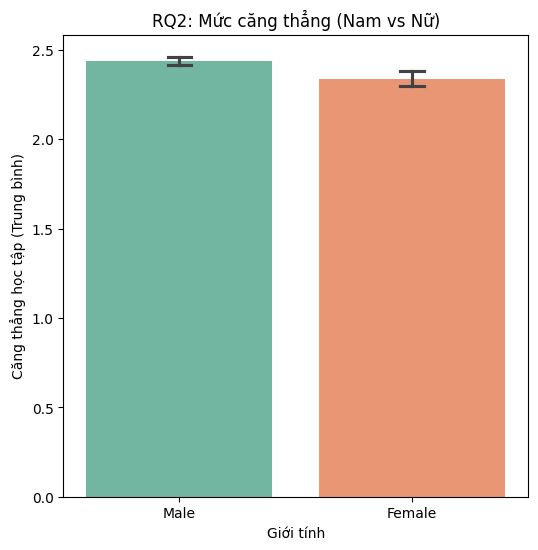

In [ ]:
# RQ2: Academic Stress Level by Gender
plt.figure(figsize=(6, 6))
sns.barplot(x='Gender', y='Academic_Stress_Level', data=df, errorbar='se', capsize=.1, palette='Set2', hue='Gender', legend=False)
plt.title('RQ2: Mức căng thẳng (Nam vs Nữ)')
plt.xticks([0, 1], ['Male', 'Female'])
plt.xlabel('Giới tính')
plt.ylabel('Căng thẳng học tập (Trung bình)')
plt.show()

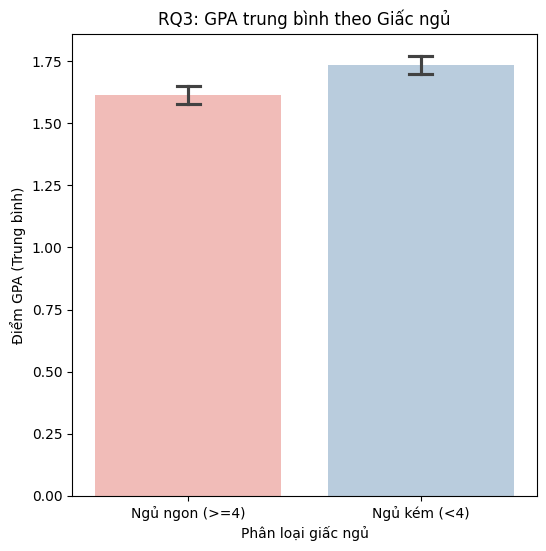

In [ ]:
# RQ3: Average GPA Rating by Sleep Category
df['Sleep_Category'] = np.where(df['Overall_Sleep_Quality'] >= 4, 'Ngủ ngon (>=4)', 'Ngủ kém (<4)')
plt.figure(figsize=(6, 6))
sns.barplot(x='Sleep_Category', y='GPA_Rating', data=df, errorbar='se', capsize=.1, palette='Pastel1', hue='Sleep_Category', legend=False)
plt.title('RQ3: GPA trung bình theo Giấc ngủ')
plt.xlabel('Phân loại giấc ngủ')
plt.ylabel('Điểm GPA (Trung bình)')
plt.show()